In [77]:
class LR:
    def __init__(self):
        self.m = None
        self.b = None
    def fit(self,X_train,y_train):
        n = 0
        d = 0
        for i in range(X_train.shape[0]):
            n=n+((X_train[i] -X_train.mean())*(y_train[i]-y_train.mean()))
        for i in range(X_train.shape[0]):
            d = d+((X_train[i]-X_train.mean())**2)
        
        self.m = n/d
        self.b = y_train.mean()- (self.m*X_train.mean())

        print("m = " , self.m)
        print("b = ",self.b)

    def predict(self ,X_test):
        return self.m*X_test + self.b



In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [79]:
X = df['cgpa'].values
y = df['package'].values
y

array([3.26, 1.98, 3.25, 3.67, 3.57, 2.99, 2.6 , 2.48, 2.31, 3.51, 1.86,
       2.6 , 3.65, 2.89, 3.42, 3.23, 2.35, 2.09, 2.98, 2.83, 3.16, 2.93,
       2.3 , 2.48, 2.71, 3.65, 3.42, 2.16, 2.24, 3.49, 3.26, 3.89, 3.08,
       2.73, 3.42, 2.87, 2.84, 2.43, 4.36, 3.33, 4.02, 2.7 , 2.54, 2.76,
       1.86, 3.58, 2.26, 3.26, 4.09, 4.62, 4.43, 3.79, 4.11, 2.61, 3.09,
       3.39, 2.74, 1.94, 3.09, 3.31, 2.19, 1.61, 2.09, 4.25, 2.92, 3.81,
       1.63, 2.89, 2.99, 2.94, 2.35, 3.34, 3.62, 4.03, 3.44, 3.28, 3.15,
       4.6 , 2.21, 3.  , 3.44, 2.2 , 2.17, 3.49, 1.53, 1.48, 2.77, 3.55,
       1.48, 2.72, 2.66, 2.14, 4.  , 3.08, 2.42, 2.79, 2.61, 2.84, 3.83,
       3.24, 4.14, 3.52, 1.37, 3.  , 3.74, 2.82, 2.19, 2.59, 3.54, 4.06,
       3.76, 2.25, 4.1 , 2.37, 1.87, 4.21, 3.33, 2.99, 2.88, 2.65, 1.73,
       3.02, 2.01, 2.3 , 2.31, 3.16, 2.6 , 3.11, 3.34, 3.12, 2.49, 2.01,
       2.48, 2.58, 2.83, 2.6 , 2.1 , 3.13, 3.89, 2.4 , 3.15, 3.18, 3.04,
       1.54, 2.42, 2.18, 2.46, 2.21, 3.4 , 3.67, 2.

In [80]:
from sklearn.model_selection import train_test_split

X_train , X_test ,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [81]:
lr = LR()

lr.fit(X_train,y_train)


m =  0.5742564727019197
b =  -1.0270069374542108


In [82]:
print(lr.predict(X_test[0]))

2.7803134765595168


In [83]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

In [84]:
reg.fit(X_train.reshape(-1,1),y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [85]:
y_pred = reg.predict(X_test.reshape(-1,1))

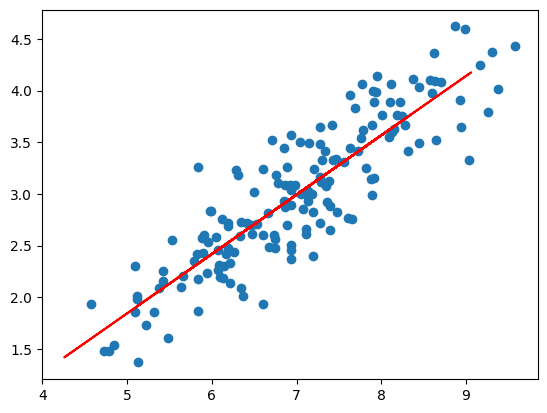

In [94]:
plt.scatter(X_train,y_train)
plt.plot(X_test,y_pred,color='red')
plt.show()

In [87]:
reg.predict(X_test[0].reshape(-1,1))

array([2.78031348])

In [88]:
reg.coef_

array([0.57425647])

In [89]:
reg.intercept_

np.float64(-1.0270069374542108)

In [109]:
from sklearn.metrics import mean_absolute_error ,mean_squared_error,r2_score
print("MAE = ",mean_absolute_error(y_test,y_pred))
print("MSE = ",mean_squared_error(y_test,y_pred))
print("RMSE = ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2score = ",r2_score(y_test,y_pred))
adjr2 = 1 - (1-(r2_score(y_test,y_pred)*(40-1)))/(40-1-2)
print("Adjusted R2score =",adjr2)

MAE =  0.23150985393278373
MSE =  0.08417638361329656
RMSE =  0.2901316659954521
R2score =  0.7730984312051673
Adjusted R2score = 1.7878605085676087
